##### The Story: You are a Data Analyst for EcoGrid, a startup managing electric vehicle (EV) charging stations across the country. Your goal is to analyze station performance, detect inefficiencies, and prepare a "Clean Energy Report" for investors. However, the data coming from the field sensors is messy, inconsistent, and contains several technical errors that must be resolved before any analysis can happen.

In [49]:
import pandas as pd
import numpy as np

# Reproducibility
np.random.seed(42)
rows = 500

data = {
    'Station_ID': [f' EV-{i} ' for i in range(1000, 1000 + rows)], # Whitespace issue
    'Region': np.random.choice(['North', 'South', 'East', 'West', 'north', 'WEST '], rows), # Case inconsistency
    'Install_Date': pd.date_range(start='2022-01-01', periods=rows, freq='D'),
    'Energy_Output_kWh': np.random.uniform(50, 500, rows).tolist(),
    'User_Rating': np.random.uniform(1, 5, rows).tolist(),
    'Charging_Fee': np.random.uniform(5, 30, rows).tolist(),
    'Status': np.random.choice(['Active', 'Offline', 'Under Repair', '??', 'NULL'], rows), # Garbage values
    'Uptime_Percentage': np.random.uniform(0.7, 1.0, rows).tolist(),
    'Maintenance_Contact': [f'operator_{np.random.randint(1, 15)}@ecogrid.com' for _ in range(rows)]
}

df = pd.DataFrame(data)

# Injecting the "TypeError" you encountered
# To simulate the error, we force the column to object first so it accepts the string
df['Energy_Output_kWh'] = df['Energy_Output_kWh'].astype(object)
df.iloc[10:15, 3] = "FAULT_404" 

# Injecting missing values and duplicates
df.iloc[100:110, 4] = np.nan       # Missing ratings
df.iloc[200:205, 7] = 1.25         # Logical error (Percentage > 1.0)
df = pd.concat([df, df.iloc[[50, 51]]]) # Duplicates

df.to_csv('ecogrid_raw.csv', index=False)
print("Dataset 'ecogrid_raw.csv' created.")

Dataset 'ecogrid_raw.csv' created.


### Task 1
Task 1: Structural Clean-up
The Goal: Remove leading/trailing whitespaces from Station_ID and fix the casing/spacing in the Region column.

End Result: A clean list of four unique regions: ['North', 'South', 'East', 'West'].

In [50]:
df['Station_ID'] = df['Station_ID'].str.strip()

df['Region'] = df['Region'].str.capitalize().str.strip()


### Task 2
The Goal: Convert Energy_Output_kWh back to a float. You must handle the 'FAULT_404' strings—decide whether to replace them with 0 or the column's average.

End Result: The column is a float64 type and can be used for calculations.

In [51]:
df['Energy_Output_kWh'] = df['Energy_Output_kWh'].replace("FAULT_404",0)

energy_mean = df['Energy_Output_kWh'].mean()
df['Energy_Output_kWh'] = df['Energy_Output_kWh'].replace(0, energy_mean)

df['Energy_Output_kWh'] = df['Energy_Output_kWh'].astype(float)

### Task 3
The Goal: 1. Fill the missing User_Rating values with the median rating.
2. Any Uptime_Percentage above 1.0 is a sensor error; cap these at 1.0.

End Result: Statistically valid values in both columns.

In [52]:
rating_mean = df['User_Rating'].mean()
df['User_Rating'] = df['User_Rating'].fillna(rating_mean)

threshold = 1 # setting limit
error_scores = df[df['Uptime_Percentage'] > 1] # setting list to review


df['Uptime_Percentage'] = df['Uptime_Percentage'].clip(upper=1.0)

error_scores # validation

,Station_ID,Region,Install_Date,Energy_Output_kWh,User_Rating,Charging_Fee,Status,Uptime_Percentage,Maintenance_Contact
200,EV-1200,North,2022-07-20,152.889262,2.275010,19.182805,NULL,1.25,operator_5@ecogrid.com
201,EV-1201,West,2022-07-21,352.265308,3.503566,11.414070,??,1.25,operator_10@ecogrid.com
202,EV-1202,North,2022-07-22,328.157708,4.543911,29.073172,Active,1.25,operator_1@ecogrid.com
203,EV-1203,West,2022-07-23,211.173223,3.463453,17.088641,NULL,1.25,operator_1@ecogrid.com
204,EV-1204,North,2022-07-24,101.100916,1.931838,25.149814,??,1.25,operator_6@ecogrid.com


### Task 4
The Goal: Identify and remove duplicate rows. In the Status column, replace "??", "NULL", and any actual blanks with the label "Unknown".

End Result: Exactly 500 unique, properly categorized rows.

In [53]:
df['Status'].unique() # review unique values
blank_names = df[df['Status'].isna()] # test for blank values
blank_names # displaying blank values

status_mapping = {
    '??' : 'Unknown',
    'NULL' : 'Unknown'
}

df['Status'] = df['Status'].replace(status_mapping)
df['Status'].unique() # review unique values after task

<StringArray>
['Unknown', 'Offline', 'Active', 'Under Repair']
Length: 4, dtype: str

### Task 5
The Goal: 1. Create a Total_Revenue column (Energy_Output_kWh * Charging_Fee).
2. Create a Year_Installed column extracted from the Install_Date.

End Result: New data dimensions that didn't exist in the raw file.

In [54]:
df['Energy_Output_kWh'].value_counts()
df['Charging_Fee'].value_counts()

df['Total_Revenue'] = df['Energy_Output_kWh'] * df['Charging_Fee']

df['Install_Date'] = pd.to_datetime(df['Install_Date']) # convert to datetime
df['Year_Installed'] = df['Install_Date'].dt.year

### Task 6
The Goal: Create a summary table showing the Total Revenue and Average User Rating per Region, but only for stations that are "Active".

End Result: A small DataFrame showing which regions are the most profitable.

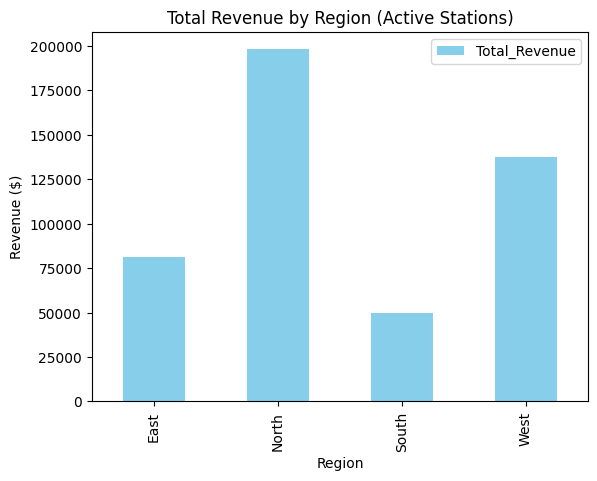

In [55]:
summary = df[df['Status'] == 'Active'].groupby('Region').agg(
    Total_Revenue=('Total_Revenue', 'sum'),
    Avg_User_Rating=('User_Rating', 'mean')  # Change 'Rating' to your actual column name
).reset_index()
summary


import matplotlib.pyplot as plt

summary.plot(kind='bar', x='Region', y='Total_Revenue', color='skyblue')
plt.title('Total Revenue by Region (Active Stations)')
plt.ylabel('Revenue ($)')
plt.show()

### Task 7:
The Goal: Find the "Top 5 Critical Stations" defined as: Stations in the "East" or "West" regions with an Uptime_Percentage below 80% and a User_Rating below 3.0.

End Result: A targeted list for the maintenance team to visit.

In [56]:
df_regions = df[(df['Region'] == 'East') | (df['Region'] == 'West')]
df_uptime = df_regions[(df_regions['Uptime_Percentage'] < 0.8)]
df_rating = df_uptime[df_uptime['User_Rating'] < 3]
# chained instead of mask

df_sorted = df_rating.sort_values(by='Uptime_Percentage', ascending=True)
df_sorted.head(5)


,Station_ID,Region,Install_Date,Energy_Output_kWh,User_Rating,Charging_Fee,Status,Uptime_Percentage,Maintenance_Contact,Total_Revenue,Year_Installed
405,EV-1405,West,2023-02-10,294.598788,1.130105,11.495330,Under Repair,0.700864,operator_1@ecogrid.com,3386.510344,2023
33,EV-1033,West,2022-02-03,193.539034,1.624610,26.768748,Offline,0.700876,operator_2@ecogrid.com,5180.797529,2022
290,EV-1290,West,2022-10-18,280.254849,1.324185,21.622793,Unknown,0.701700,operator_7@ecogrid.com,6059.892618,2022
152,EV-1152,East,2022-06-02,258.664282,2.443896,20.086215,Under Repair,0.702013,operator_9@ecogrid.com,5195.586343,2022
138,EV-1138,East,2022-05-19,333.229387,2.336976,25.445855,Active,0.703693,operator_7@ecogrid.com,8479.306802,2022


##### Task 8: Dynamic Tiering (Conditional Logic)
The Business Need: Investors want to categorize stations based on their "Revenue Efficiency."
The Task: Create a new column called Performance_Tier.

Tier A: Status is "Active" AND Total_Revenue is in the top 25% (use quantiles).

Tier B: Status is "Active" AND Total_Revenue is between the 50th and 75th percentile.

Tier C: Everything else.
Functions to research: np.select() or pd.qcut(). np.select is generally preferred for complex multi-condition logic.
End Result: A column that helps management instantly identify their "Star" stations versus "Underperformers."

In [57]:
# calculate the values for the 50th and 75th percentiles
q50 = df['Total_Revenue'].quantile(0.50)
q75 = df['Total_Revenue'].quantile(0.75)

# conditions for tiers
conditions = [
    (df['Status'] == 'Active') & (df['Total_Revenue'] >= q75), # Tier A
    (df['Status'] == 'Active') & (df['Total_Revenue'] >= q50) & (df['Total_Revenue'] < q75) # Tier B
]

# define the tiers
choices = ['Tier A', 'Tier B']

# new column
df['Performance_Tier'] = np.select(conditions, choices, default = 'Tier C')


#### Task 9: The "Operator Performance" Lookup (Merging/Joining)
The Business Need: We have a separate list of operator performance scores, and we need to see if "bad" operators correlate with "Offline" stations.

Task 1 - Create a second, small DataFrame called df_operators containing two columns: Maintenance_Contact (unique emails from your main list) and an Experience_Level (randomly assign 'Junior', 'Mid', 'Senior').

Task 2 - Merge this new DataFrame into your main df so every station row now knows the experience level of its operator.
Functions to research: pd.merge() (specifically a "left join").
End Result: Your main table now has an extra column Experience_Level. This simulates the real-world reality where data lives in multiple tables.

In [58]:
unique_contacts = df['Maintenance_Contact'].unique()
levels = ['Junior', 'Mid', 'Senior']

# new df
df_operators = pd.DataFrame({
    'Unique_ID' : unique_contacts,
    'Experience_Level' : np.random.choice(levels, size = len(unique_contacts))
     })

# controlized randomness
df_operators['Experience_Level'] = np.random.choice(levels,
                                              size=len(unique_contacts),
                                              p=[0.5,0.3,0.2])


merged_df = pd.merge(
    left = df,
    right = df_operators,
    left_on = 'Maintenance_Contact',
    right_on = 'Unique_ID',
    how='left'
)

merged_df = merged_df.drop(columns='Unique_ID')

merged_df.head()

,Station_ID,Region,Install_Date,Energy_Output_kWh,User_Rating,Charging_Fee,Status,Uptime_Percentage,Maintenance_Contact,Total_Revenue,Year_Installed,Performance_Tier,Experience_Level
0,EV-1000,West,2022-01-01,127.940841,1.712144,26.706813,Unknown,0.766068,operator_13@ecogrid.com,3416.892081,2022,Tier C,Junior
1,EV-1001,North,2022-01-02,245.233242,4.844281,23.179227,Offline,0.846512,operator_5@ecogrid.com,5684.316925,2022,Tier C,Mid
2,EV-1002,East,2022-01-03,229.327130,1.594651,23.567663,Active,0.921270,operator_8@ecogrid.com,5404.704535,2022,Tier B,Senior
3,EV-1003,North,2022-01-04,327.132544,2.658496,15.637333,Offline,0.857572,operator_8@ecogrid.com,5115.480646,2022,Tier C,Senior
4,EV-1004,North,2022-01-05,335.792143,1.341399,13.648375,Unknown,0.709794,operator_4@ecogrid.com,4583.017026,2022,Tier C,Mid


#### Task 10: Time-Series Resampling (Rolling Windows)
The Business Need: Sensor data is volatile. We want to see a "smoothed out" view of energy output to spot long-term trends.

Task: 
1. Ensure your Install_Date is set as the Index of your DataFrame.
2. Calculate a 7-day Rolling Average of the Energy_Output_kWh.
3. Create a summary that shows the Total Energy Output per Month (not per day).

Functions to research: .rolling(window=7).mean() and .resample('M').sum().
End Result: You move from looking at "Daily Spikes" to seeing "Monthly Trends." This is essential for any financial or sensor-based portfolio project.

In [62]:
if 'Install_Date' in merged_df.columns:
    merged_df['Install_Date'] = pd.to_datetime(merged_df['Install_Date'])
    merged_df.set_index('Install_Date', inplace=True)
    merged_df.sort_index(inplace=True)

merged_df['Energy_7D_Avg'] = merged_df['Energy_Output_kWh'].rolling(window=7).mean()

monthly_summary = merged_df['Energy_Output_kWh'].resample('ME').sum()

### The Question: "Does the experience level of the operator affect the average Energy Output? And is there a specific month where Junior operators struggled the most?"

In [63]:
merged_df.index

DatetimeIndex(['2022-01-01', '2022-01-02', '2022-01-03', '2022-01-04',
               '2022-01-05', '2022-01-06', '2022-01-07', '2022-01-08',
               '2022-01-09', '2022-01-10',
               ...
               '2023-05-06', '2023-05-07', '2023-05-08', '2023-05-09',
               '2023-05-10', '2023-05-11', '2023-05-12', '2023-05-13',
               '2023-05-14', '2023-05-15'],
              dtype='datetime64[us]', name='Install_Date', length=502, freq=None)

<Axes: title={'center': 'Energy Output Trend by Experience'}, xlabel='Install_Date'>

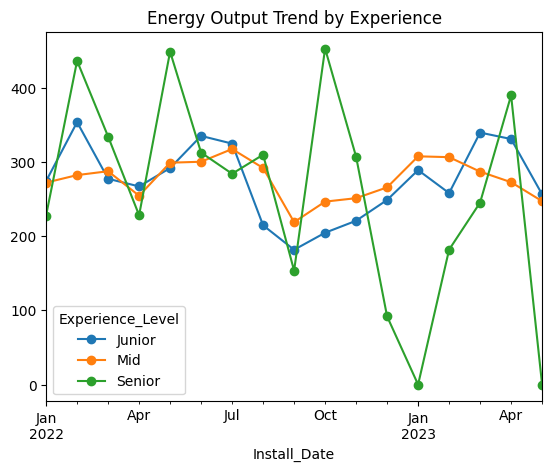

In [70]:
# group Average kWh output per Experience Level
exp_performance = merged_df.groupby('Experience_Level')['Energy_Output_kWh'].mean()

monthly_experience = merged_df.groupby(['Experience_Level', merged_df.index.to_period('M')])['Energy_Output_kWh'].mean()

performance_pivot = monthly_experience.unstack(level=0)

performance_pivot = performance_pivot.fillna(0)

# Quick visualization
performance_pivot.plot(kind='line', marker='o', title='Energy Output Trend by Experience')